In [9]:
import numpy as np
import matplotlib.pyplot as plt


In [10]:
R = 6378 # radius earth [km]
M_planet = 5.98e24 # mass earth [kg]
h = 8.5 # scaleheight earth [km]
M_atm = 5.15e18 # earth atmosphere mass [kg]
M0 = M_atm
rho_0 = 1.293 # density at earth surface [kg/m^3]
rho = 5.51e12 # density of earth [kg/km^3]


In [11]:
N_0 = 1 # impactor flux
r_0 = 1 # impactor radius 

In [12]:
q = [3.9, 3.4, 3.1, 2.8, 2.5, 2.0, 1.5]
C = [None, None, None, 2.8, 1.9, 1.3, 1.1]


In [13]:
def Matm_mimp(q, C, r_max):
    """"""
    r_min = (3*rho_0 / rho)**(1/3) * h
    r_cap = (3*np.sqrt(2*np.pi)*rho_0 / (4*rho))**(1/3) * (h*R)**(1/2)
    r_max = 1
    
    if 3 < q < 4:
        dM_dm = - ((4-q)/((q-1)*(q-3))) * (r_min/r_max)**(-q+4) # + f
    elif 1 < q < 3:
        dM_dm = - C * (2*h / (np.pi*R))**(1/2) * ((4-q)/(q-1)) * (r_cap/r_max)**(-q+4) # + f
        
    return dM_dm


In [14]:
r = np.geomspace(1.000001,3000,1000)

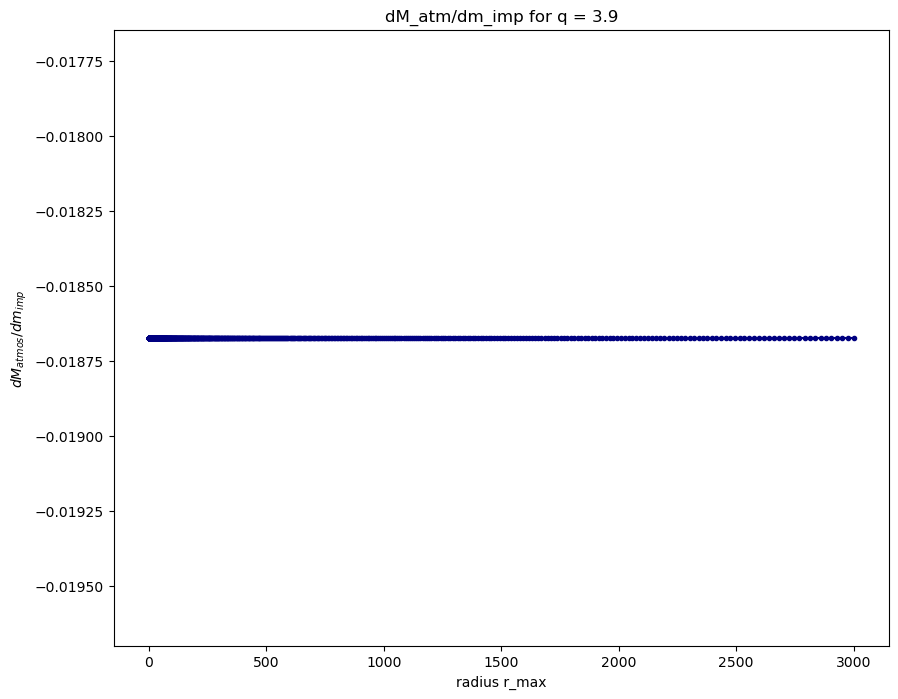

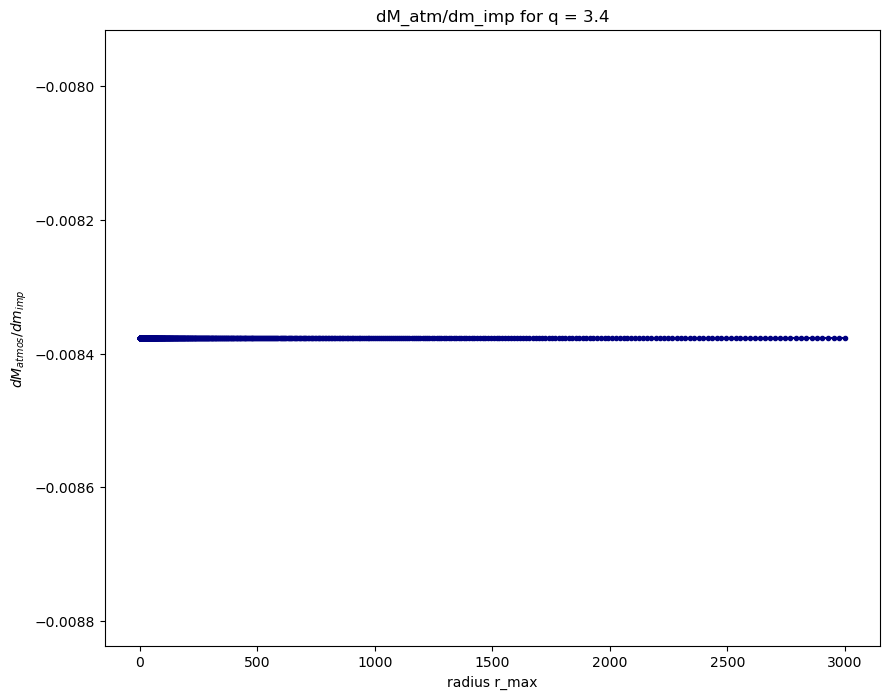

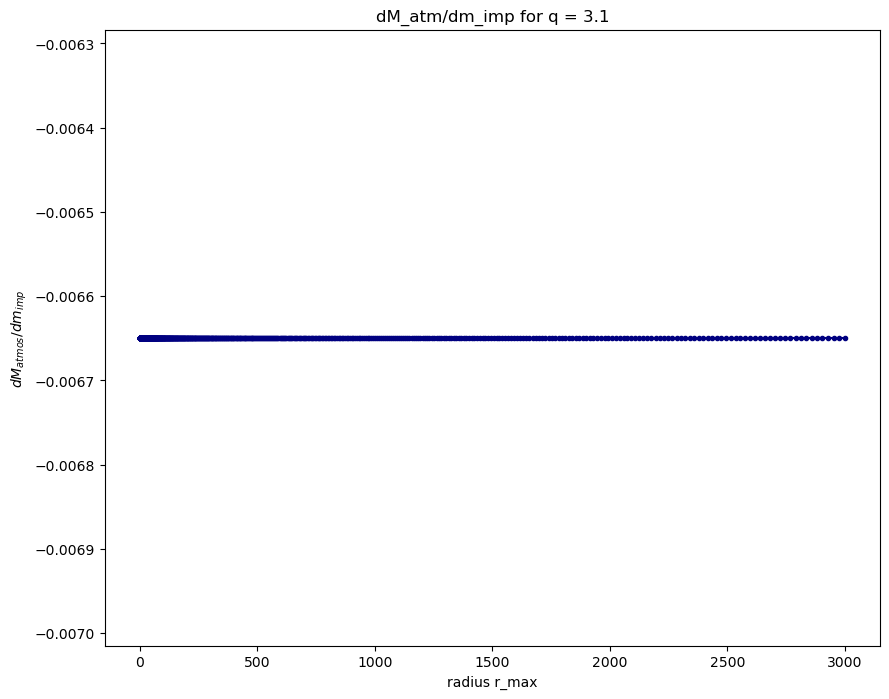

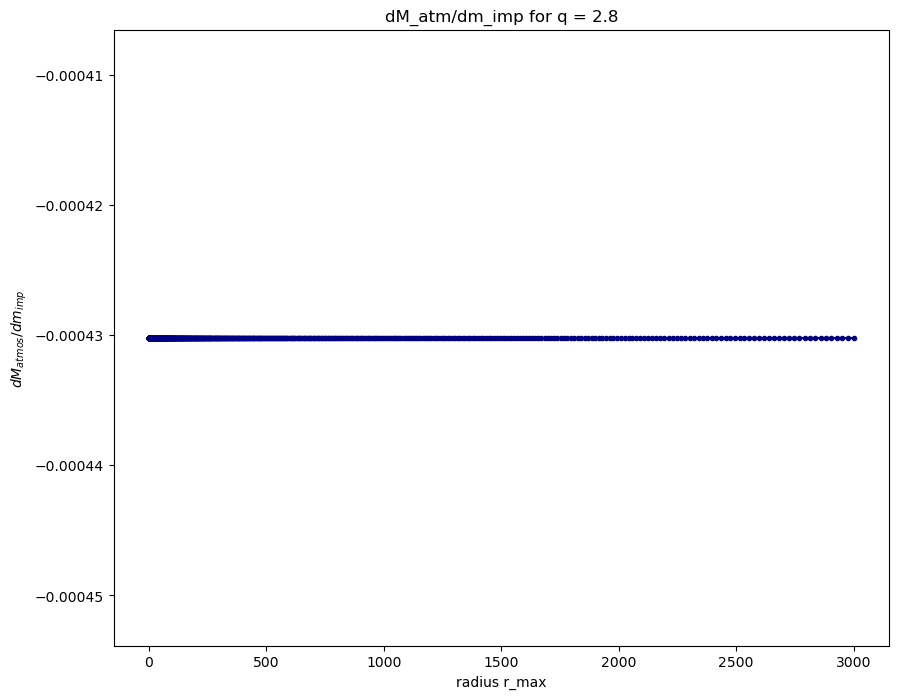

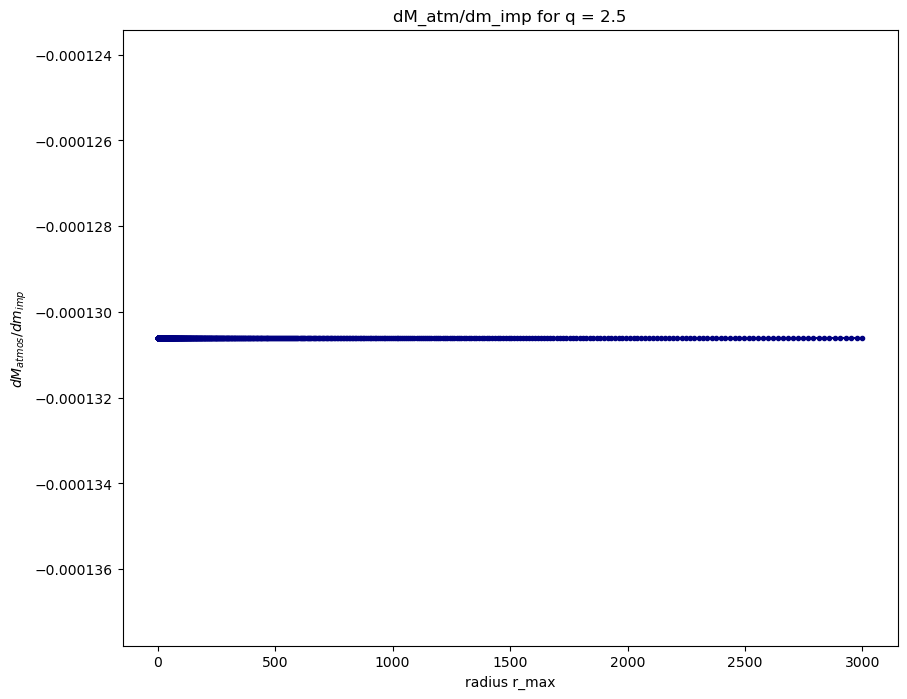

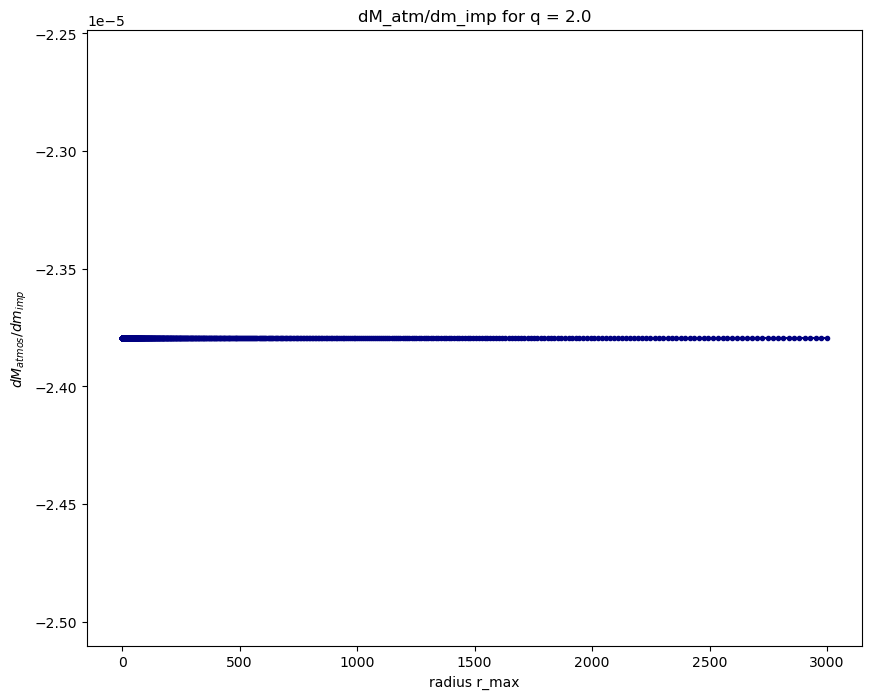

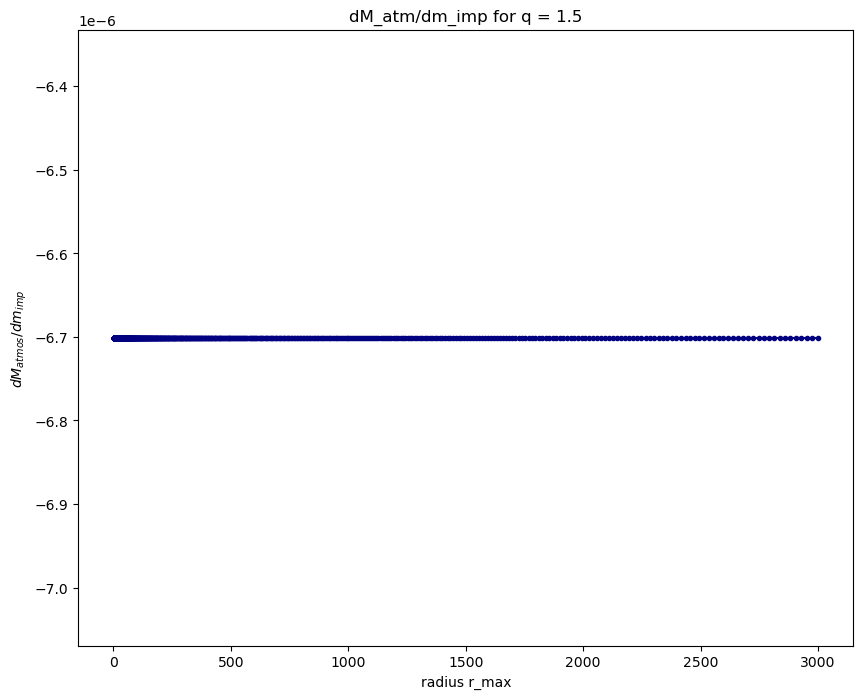

In [16]:
for i in range(len(q)):
    dM_dm = [Matm_mimp(q[i], C[i], _) for _ in r]
    dM_dm = np.array(dM_dm)
    
    plt.figure(figsize=(10,8))
    plt.plot(r, dM_dm, color='navy', marker='.')
    plt.xlabel('radius r_max')
    plt.ylabel(r'$dM_{atmos}/dm_{imp}$')
    plt.title(f'dM_atm/dm_imp for q = {q[i]}')
    # plt.legend()
    # plt.savefig('Mtotal_vs_impactor_rad')
    plt.show()